# Exploración de Datos - Riesgos Laborales Colombia

Este notebook realiza una exploración inicial del dataset de **Estadísticas de Riesgos Laborales** proporcionado por Positiva Compañía de Seguros. El objetivo es comprender la estructura de los datos, identificar patrones y preparar el dataset para el preprocesamiento.

## Objetivos:
1. Cargar y explorar el dataset.
2. Analizar la calidad de los datos (valores faltantes, duplicados, outliers).
3. Generar estadísticas descriptivas y visualizaciones.
4. Documentar hallazgos y recomendaciones para el preprocesamiento.

## 1. Configuración Inicial

### 1.1 Importar Librerías

Importamos las librerías necesarias para el análisis exploratorio de datos.

In [21]:
# Instala las librerias de pandas, numpy, matplotlib y seaborn
!pip install pandas numpy matplotlib seaborn

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Montar Google Drive (para Colab)

Si estás ejecutando este notebook en Google Colab, es necesario montar Google Drive para acceder a los archivos del proyecto.

In [5]:
# Verificar si estamos en Google Colab
try:
    from google.colab import drive
    # Montar Google Drive
    drive.mount('/content/drive')
    # Definir ruta base del proyecto en Google Drive
    BASE_PATH = '/content/drive/MyDrive/DatosARLBog'
    print(f"✅ Google Drive montado correctamente")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")
except:
    # Si no estamos en Colab, usar la ruta local
    BASE_PATH = '/Users/jualgozo/Documents/datoscol/DatosArl_Mac'
    print(f"💻 Ejecutando en entorno local")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")

💻 Ejecutando en entorno local
📁 Ruta base del proyecto: /Users/jualgozo/Documents/datoscol/DatosArl_Mac


### 1.3 Definir Rutas de Archivos

Definimos las rutas de los archivos del proyecto, incluyendo el dataset original y los directorios de salida.

In [6]:
# Definir rutas de archivos
DATA_PATH = Path(BASE_PATH)
RAW_DATA_FILE = DATA_PATH / 'main_dataset.csv'
PROCESSED_DATA_DIR = DATA_PATH / 'data' / 'processed'
REPORTS_DIR = DATA_PATH / 'reports'
MODELS_DIR = DATA_PATH / 'models'

# Crear directorios si no existen
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Directorio de datos: {DATA_PATH}")
print(f"📊 Archivo de datos: {RAW_DATA_FILE}")
print(f"📁 Directorio de datos procesados: {PROCESSED_DATA_DIR}")
print(f"📈 Directorio de reportes: {REPORTS_DIR}")
print(f"🤖 Directorio de modelos: {MODELS_DIR}")

📂 Directorio de datos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac
📊 Archivo de datos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/main_dataset.csv
📁 Directorio de datos procesados: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed
📈 Directorio de reportes: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports
🤖 Directorio de modelos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/models


## 2. Carga y Exploración Inicial de Datos

### 2.1 Cargar el Dataset

Cargamos el dataset de riesgos laborales y realizamos una exploración inicial.

In [7]:
# Cargar el dataset
try:
    df = pd.read_csv(RAW_DATA_FILE)
    print(f"✅ Dataset cargado correctamente")
    print(f"📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo {RAW_DATA_FILE}")
    print("Por favor, verifica que el archivo esté en la ruta correcta.")

✅ Dataset cargado correctamente
📊 Dimensiones: 61368 filas x 14 columnas


### 2.2 Vista Previa de los Datos

Mostramos las primeras filas del dataset para entender su estructura.

In [8]:
# Mostrar las primeras filas del dataset
print("=" * 80)
print("📋 PRIMERAS 5 FILAS DEL DATASET")
print("=" * 80)
df.head()

📋 PRIMERAS 5 FILAS DEL DATASET


,DPTO,MPIO,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL
0,ANTIOQUIA,MEDELLIN,1423,2026,4,1131201,24,0,0,0,0,0,0,0
1,ANTIOQUIA,MEDELLIN,1423,2026,4,1131202,10,0,0,0,0,0,0,0
2,ANTIOQUIA,MEDELLIN,1423,2026,4,1139301,0,0,0,0,0,0,0,0
3,ANTIOQUIA,MEDELLIN,1423,2026,4,1141001,688,29,0,0,0,0,0,0
4,ANTIOQUIA,MEDELLIN,1423,2026,4,1454101,323,0,2,2,2,0,0,0


In [9]:
# Mostrar información general del dataset
print("=" * 80)
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
df.info()

📊 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   DPTO                  61368 non-null  object
 1   MPIO                  61368 non-null  object
 2   CODIGO_DE_LA_ARL      61368 non-null  int64 
 3   AÑO_DE_INFORME        61368 non-null  int64 
 4   MES_DE_INFORME        61368 non-null  int64 
 5   ACTIVEC               61368 non-null  int64 
 6   RELA_DEP              61368 non-null  object
 7   RELA_INDEP            61368 non-null  object
 8   PRESUACCIDETRASUCE    61368 non-null  int64 
 9   MUERTES_REPOR_AT      61368 non-null  int64 
 10  NUEVAPENSIOINVA_R_AT  61368 non-null  int64 
 11  NUEVAPENSIOINVA_R_EL  61368 non-null  int64 
 12  INCAPERMAPARCIAR_AT   61368 non-null  int64 
 13  INCAPERMAPARCIAR_EL   61368 non-null  int64 
dtypes: int64(10), object(4)
memory usage: 6.6+ MB


## 3. Análisis de Calidad de Datos

### 3.1 Valores Faltantes

Identificamos la cantidad de valores faltantes por columna.

In [10]:
# Análisis de valores faltantes
print("=" * 80)
print("🔍 ANÁLISIS DE VALORES FALTANTES")
print("=" * 80)

# Calcular valores faltantes
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Crear DataFrame con resultados
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores Faltantes': missing_values.values,
    'Porcentaje (%)': missing_percentage.values
})

# Filtrar solo columnas con valores faltantes
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_df) > 0:
    print(f"\n❌ Se encontraron {len(missing_df)} columnas con valores faltantes:\n")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ No se encontraron valores faltantes en el dataset")

🔍 ANÁLISIS DE VALORES FALTANTES

✅ No se encontraron valores faltantes en el dataset


### 3.2 Registros Duplicados

Identificamos si existen filas duplicadas en el dataset.

In [11]:
# Análisis de duplicados
print("=" * 80)
print("🔍 ANÁLISIS DE DUPLICADOS")
print("=" * 80)

duplicates = df.duplicated().sum()
print(f"\n📊 Total de filas duplicadas: {duplicates}")
print(f"📊 Porcentaje de duplicados: {(duplicates / len(df)) * 100:.2f}%")

if duplicates > 0:
    print("\n⚠️ Se encontraron filas duplicadas. Se recomienda eliminarlas en el preprocesamiento.")
else:
    print("\n✅ No se encontraron filas duplicadas.")

🔍 ANÁLISIS DE DUPLICADOS

📊 Total de filas duplicadas: 0
📊 Porcentaje de duplicados: 0.00%

✅ No se encontraron filas duplicadas.


## 4. Estadísticas Descriptivas

### 4.1 Variables Numéricas

Analizamos las estadísticas descriptivas de las variables numéricas.

In [12]:
# Estadísticas descriptivas de variables numéricas
print("=" * 80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    print(f"\n📈 Total de variables numéricas: {len(numeric_cols)}")
    print(f"📋 Variables: {numeric_cols}\n")
    
    # Mostrar estadísticas descriptivas
    df[numeric_cols].describe().T
else:
    print("\n⚠️ No se encontraron variables numéricas en el dataset")

📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS

📈 Total de variables numéricas: 10
📋 Variables: ['CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL']



### 4.2 Variables Categóricas

Analizamos las estadísticas descriptivas de las variables categóricas.

In [13]:
# Estadísticas descriptivas de variables categóricas
print("=" * 80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("=" * 80)

# Seleccionar solo columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"\n📈 Total de variables categóricas: {len(categorical_cols)}")
    print(f"📋 Variables: {categorical_cols}\n")
    
    # Mostrar estadísticas descriptivas
    df[categorical_cols].describe().T
else:
    print("\n⚠️ No se encontraron variables categóricas en el dataset")

📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS

📈 Total de variables categóricas: 4
📋 Variables: ['DPTO', 'MPIO', 'RELA_DEP', 'RELA_INDEP']



## 5. Visualizaciones Exploratorias

### 5.1 Distribución de Variables Numéricas

Visualizamos la distribución de las variables numéricas clave.

📊 DISTRIBUCIÓN DE VARIABLES NUMÉRICAS


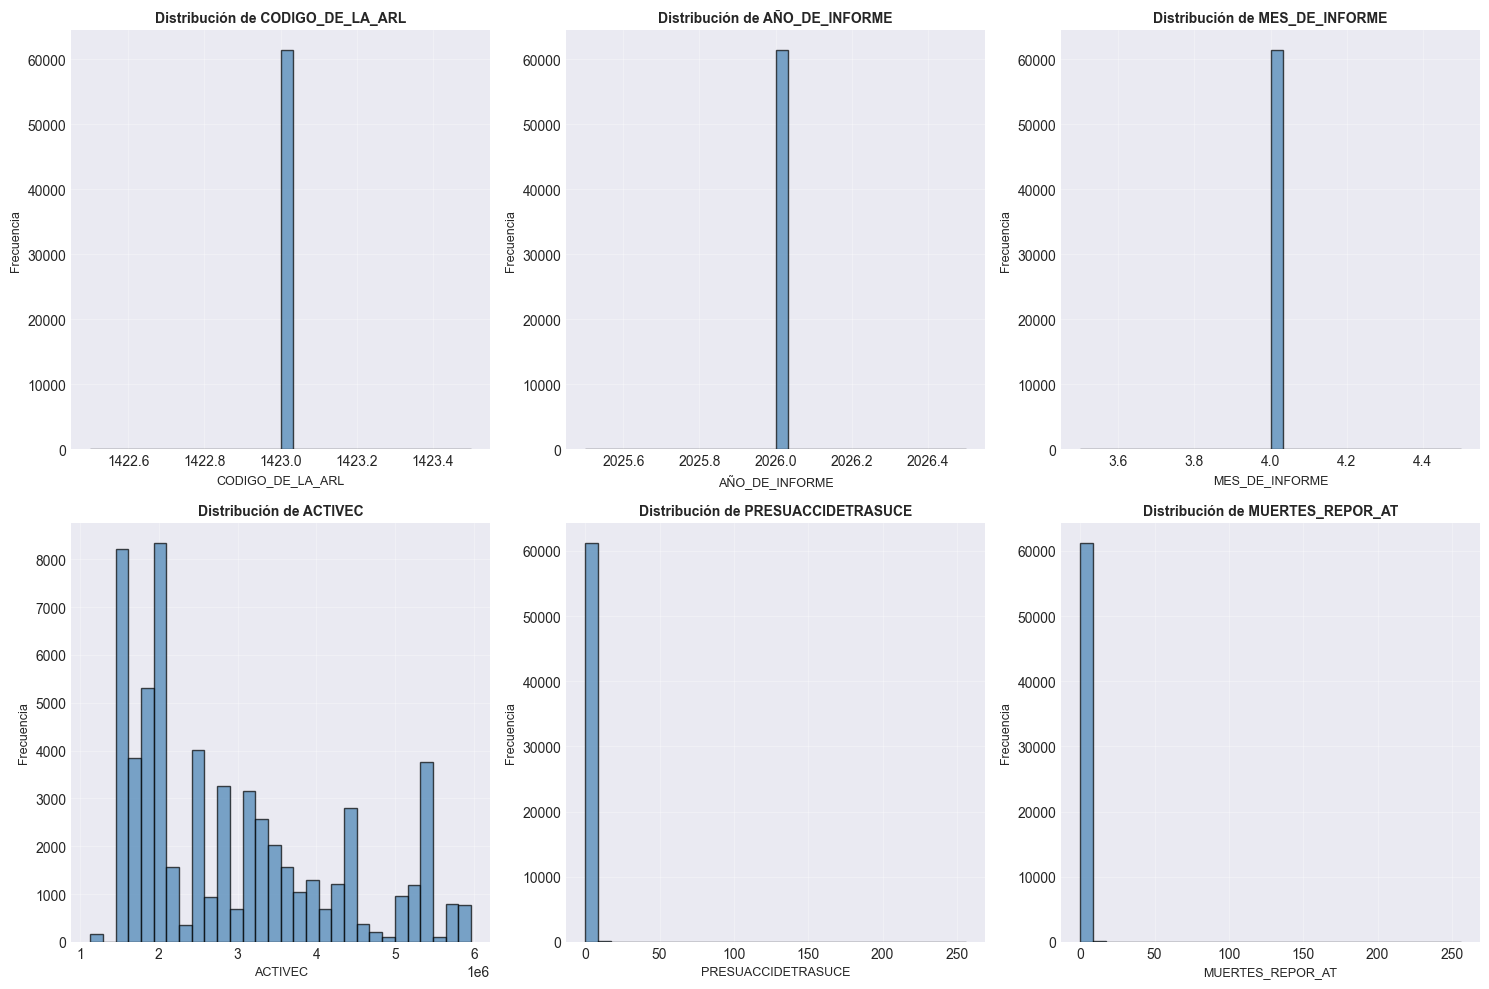


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/distribucion_variables_numericas.png


In [14]:
# Visualizar distribución de variables numéricas
if len(numeric_cols) > 0:
    print("=" * 80)
    print("📊 DISTRIBUCIÓN DE VARIABLES NUMÉRICAS")
    print("=" * 80)
    
    # Seleccionar las primeras 6 variables numéricas para visualizar
    cols_to_plot = numeric_cols[:6]
    
    # Crear subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        data = df[col].dropna()
        
        # Histograma con KDE
        ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('Frecuencia', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Ocultar ejes vacíos
    for idx in range(len(cols_to_plot), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'distribucion_variables_numericas.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'distribucion_variables_numericas.png'}")
else:
    print("\n⚠️ No hay variables numéricas para visualizar")

### 5.2 Distribución de Variables Categóricas

Visualizamos la distribución de las principales variables categóricas.

📊 DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS


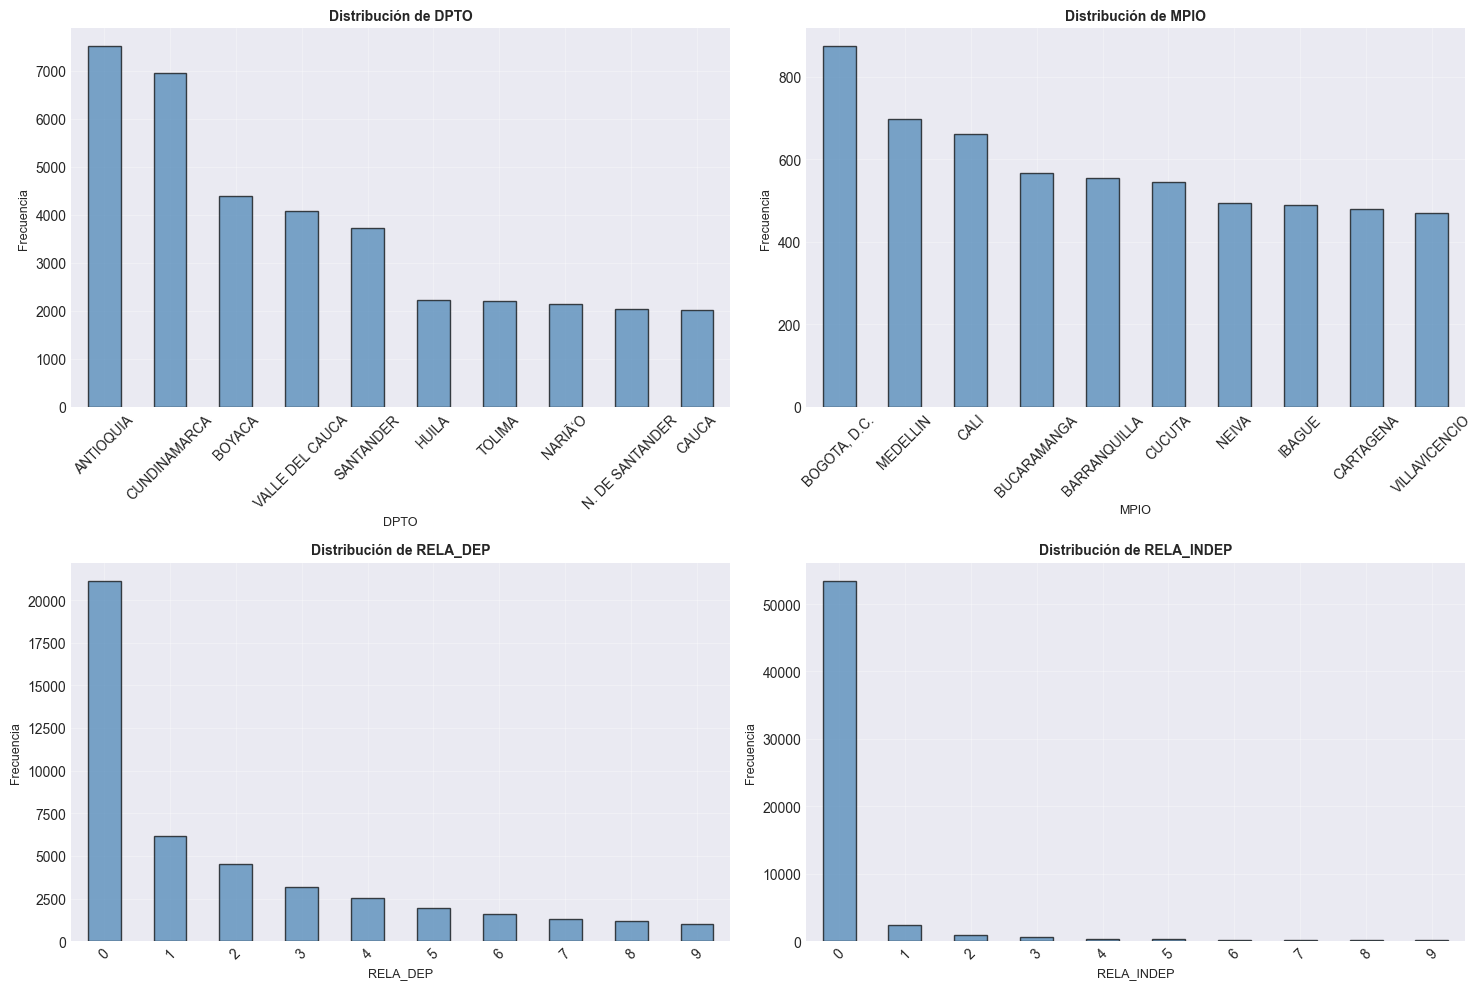


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/distribucion_variables_categoricas.png


In [15]:
# Visualizar distribución de variables categóricas
if len(categorical_cols) > 0:
    print("=" * 80)
    print("📊 DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
    print("=" * 80)
    
    # Seleccionar las primeras 4 variables categóricas para visualizar
    cols_to_plot = categorical_cols[:4]
    
    # Crear subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        
        # Contar valores únicos
        value_counts = df[col].value_counts().head(10)  # Top 10 valores
        
        # Gráfico de barras
        value_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7, edgecolor='black')
        ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('Frecuencia', fontsize=9)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    
    # Ocultar ejes vacíos
    for idx in range(len(cols_to_plot), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'distribucion_variables_categoricas.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'distribucion_variables_categoricas.png'}")
else:
    print("\n⚠️ No hay variables categóricas para visualizar")

### 5.3 Matriz de Correlación

Analizamos la correlación entre las variables numéricas.

📊 MATRIZ DE CORRELACIÓN


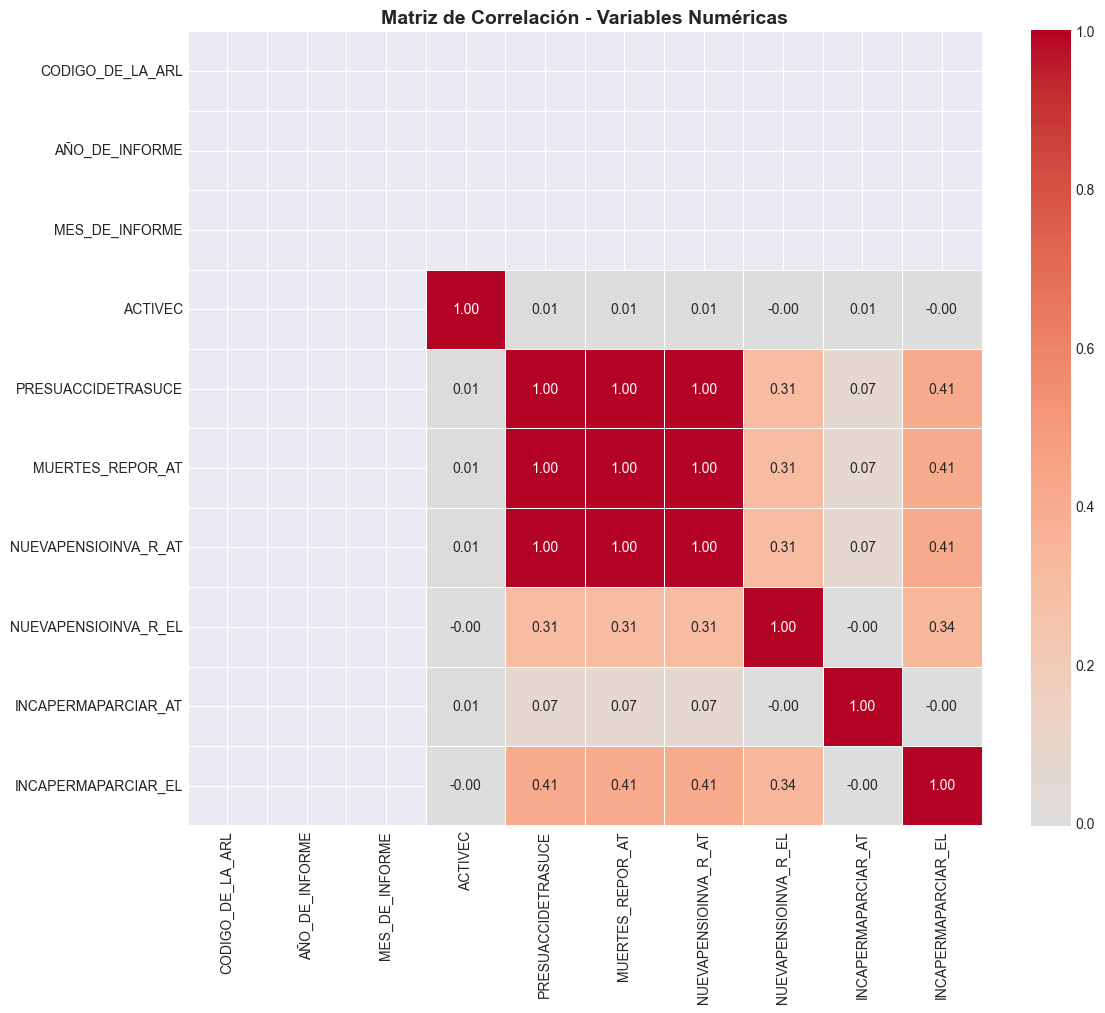


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/matriz_correlacion.png


In [16]:
# Matriz de correlación
if len(numeric_cols) > 1:
    print("=" * 80)
    print("📊 MATRIZ DE CORRELACIÓN")
    print("=" * 80)
    
    # Calcular matriz de correlación
    correlation_matrix = df[numeric_cols].corr()
    
    # Crear mapa de calor
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, fmt='.2f')
    plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'matriz_correlacion.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'matriz_correlacion.png'}")
else:
    print("\n⚠️ No hay suficientes variables numéricas para calcular la correlación")

## 6. Análisis de Variables Clave

### 6.1 Análisis por Departamento

Analizamos la distribución de accidentes y enfermedades laborales por departamento.

📊 ANÁLISIS POR DEPARTAMENTO

📈 Top 10 Departamentos con más Presuntos Accidentes:
           DPTO  PRESUACCIDETRASUCE  MUERTES_REPOR_AT  NUEVAPENSIOINVA_R_AT  NUEVAPENSIOINVA_R_EL  INCAPERMAPARCIAR_AT  INCAPERMAPARCIAR_EL
         BOGOTA                1999              1999                  1999                     5                    1                    2
      ANTIOQUIA                1142              1142                  1142                     1                    3                    0
VALLE DEL CAUCA                 576               576                   576                     0                    2                    0
   CUNDINAMARCA                 401               401                   401                     0                    0                    0
      SANTANDER                 375               375                   375                     2                    0                    0
N. DE SANTANDER                 358               358                   358   

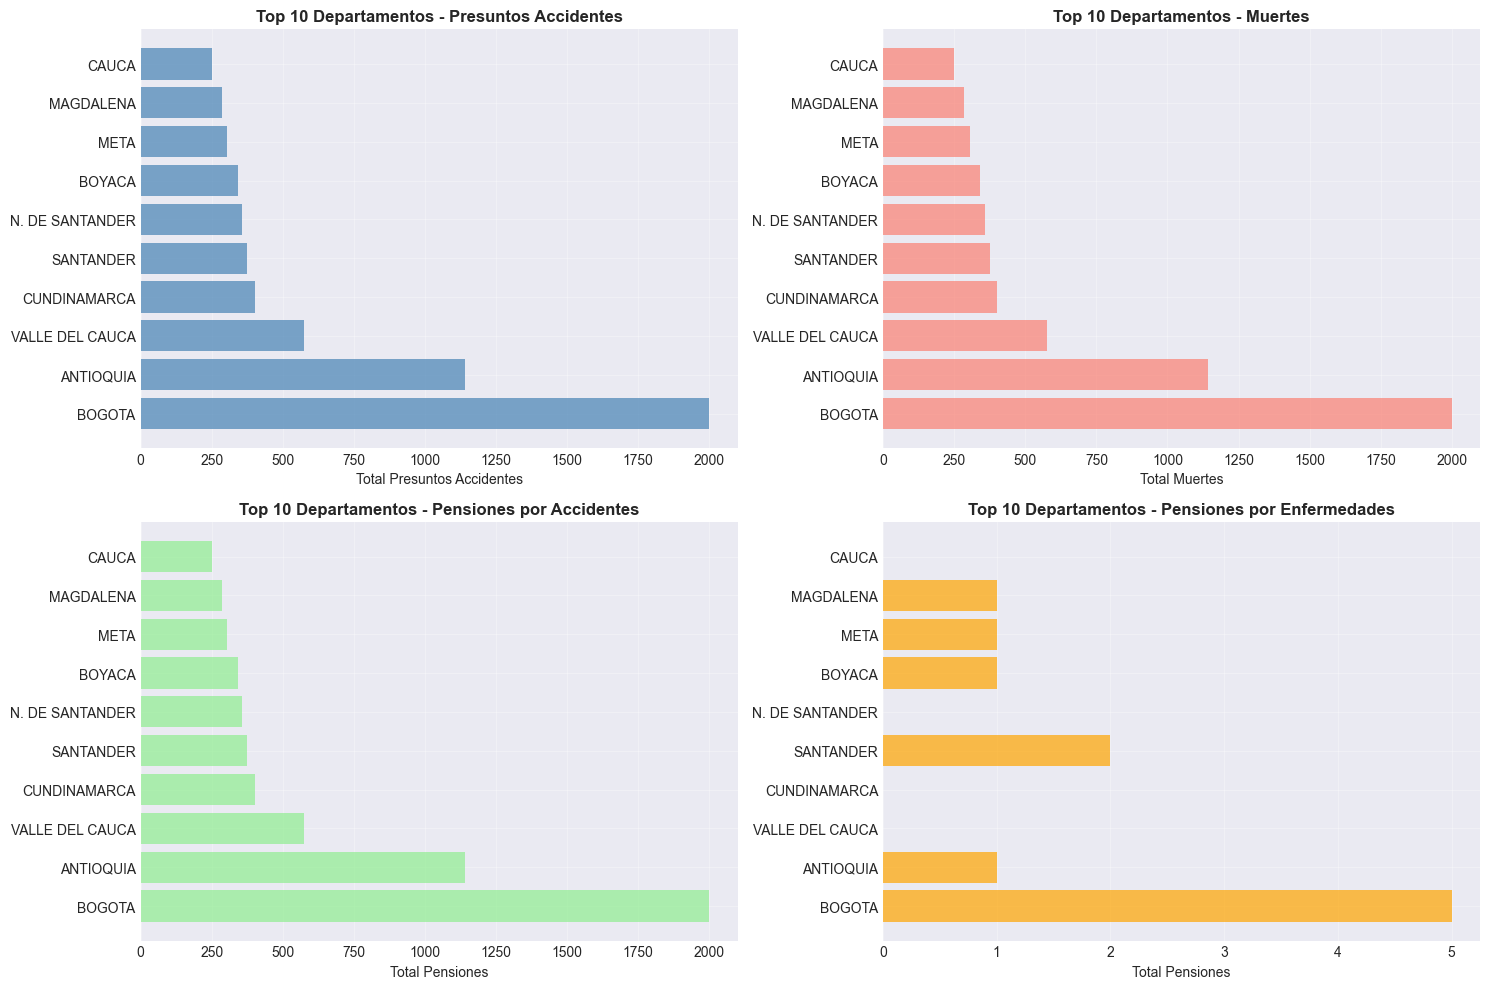


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/analisis_por_departamento.png


In [17]:
# Análisis por departamento
if 'DPTO' in df.columns:
    print("=" * 80)
    print("📊 ANÁLISIS POR DEPARTAMENTO")
    print("=" * 80)
    
    # Agrupar por departamento y calcular estadísticas
    dept_analysis = df.groupby('DPTO').agg({
        'PRESUACCIDETRASUCE': 'sum',
        'MUERTES_REPOR_AT': 'sum',
        'NUEVAPENSIOINVA_R_AT': 'sum',
        'NUEVAPENSIOINVA_R_EL': 'sum',
        'INCAPERMAPARCIAR_AT': 'sum',
        'INCAPERMAPARCIAR_EL': 'sum'
    }).reset_index()
    
    # Ordenar por presuntos accidentes
    dept_analysis = dept_analysis.sort_values('PRESUACCIDETRASUCE', ascending=False)
    
    print("\n📈 Top 10 Departamentos con más Presuntos Accidentes:")
    print(dept_analysis.head(10).to_string(index=False))
    
    # Visualizar top 10 departamentos
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Presuntos accidentes
    axes[0, 0].barh(dept_analysis.head(10)['DPTO'], dept_analysis.head(10)['PRESUACCIDETRASUCE'], color='steelblue', alpha=0.7)
    axes[0, 0].set_title('Top 10 Departamentos - Presuntos Accidentes', fontweight='bold')
    axes[0, 0].set_xlabel('Total Presuntos Accidentes')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Muertes
    axes[0, 1].barh(dept_analysis.head(10)['DPTO'], dept_analysis.head(10)['MUERTES_REPOR_AT'], color='salmon', alpha=0.7)
    axes[0, 1].set_title('Top 10 Departamentos - Muertes', fontweight='bold')
    axes[0, 1].set_xlabel('Total Muertes')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Pensiones por accidentes
    axes[1, 0].barh(dept_analysis.head(10)['DPTO'], dept_analysis.head(10)['NUEVAPENSIOINVA_R_AT'], color='lightgreen', alpha=0.7)
    axes[1, 0].set_title('Top 10 Departamentos - Pensiones por Accidentes', fontweight='bold')
    axes[1, 0].set_xlabel('Total Pensiones')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Pensiones por enfermedades
    axes[1, 1].barh(dept_analysis.head(10)['DPTO'], dept_analysis.head(10)['NUEVAPENSIOINVA_R_EL'], color='orange', alpha=0.7)
    axes[1, 1].set_title('Top 10 Departamentos - Pensiones por Enfermedades', fontweight='bold')
    axes[1, 1].set_xlabel('Total Pensiones')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'analisis_por_departamento.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'analisis_por_departamento.png'}")
else:
    print("\n⚠️ La columna 'DPTO' no está disponible en el dataset")

### 6.2 Análisis por Actividad Económica

Analizamos la distribución de riesgos laborales por actividad económica.

📊 ANÁLISIS POR ACTIVIDAD ECONÓMICA

📋 Información de la columna ACTIVEC:
   - Total de valores únicos: 999
   - Tipo de datos: int64
   - Valores más frecuentes:
ACTIVEC
1829902    1111
1841201     965
1970001     937
3360001     639
5711001     634
1949101     624
1471101     594
2014101     588
3861001     578
3473101     567
Name: count, dtype: int64

📈 Top 10 Actividades Económicas con más Presuntos Accidentes:
 ACTIVEC  PRESUACCIDETRASUCE  MUERTES_REPOR_AT  NUEVAPENSIOINVA_R_AT  NUEVAPENSIOINVA_R_EL  INCAPERMAPARCIAR_AT  INCAPERMAPARCIAR_EL
 1841201                 670               670                   670                     3                    0                    1
 2012201                 427               427                   427                     0                    1                    0
 5051001                 425               425                   425                     0                    1                    0
 3861001                 421               421   

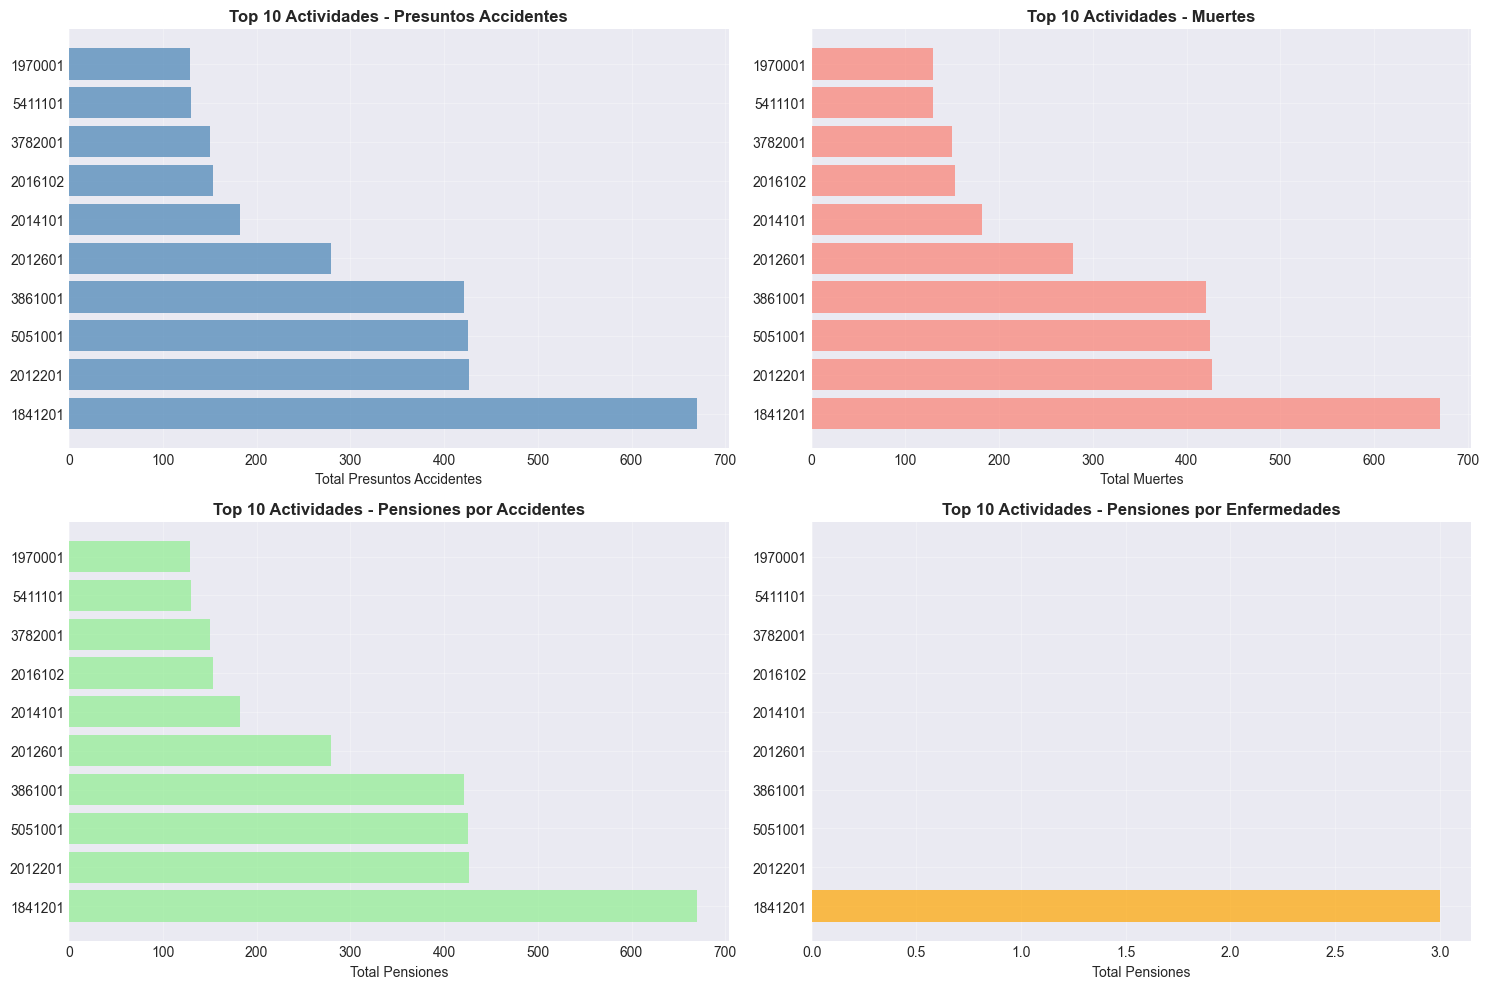


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/analisis_por_actividad.png


In [18]:
# Análisis por actividad económica
if 'ACTIVEC' in df.columns:
    print("=" * 80)
    print("📊 ANÁLISIS POR ACTIVIDAD ECONÓMICA")
    print("=" * 80)
    
    # Mostrar información sobre la columna ACTIVEC
    print(f"\n📋 Información de la columna ACTIVEC:")
    print(f"   - Total de valores únicos: {df['ACTIVEC'].nunique()}")
    print(f"   - Tipo de datos: {df['ACTIVEC'].dtype}")
    print(f"   - Valores más frecuentes:")
    print(df['ACTIVEC'].value_counts().head(10))
    
    # Agrupar por actividad económica y calcular estadísticas
    activity_analysis = df.groupby('ACTIVEC').agg({
        'PRESUACCIDETRASUCE': 'sum',
        'MUERTES_REPOR_AT': 'sum',
        'NUEVAPENSIOINVA_R_AT': 'sum',
        'NUEVAPENSIOINVA_R_EL': 'sum',
        'INCAPERMAPARCIAR_AT': 'sum',
        'INCAPERMAPARCIAR_EL': 'sum'
    }).reset_index()
    
    # Ordenar por presuntos accidentes
    activity_analysis = activity_analysis.sort_values('PRESUACCIDETRASUCE', ascending=False)
    
    print("\n📈 Top 10 Actividades Económicas con más Presuntos Accidentes:")
    print(activity_analysis.head(10).to_string(index=False))
    
    # Verificar si hay datos para graficar
    if activity_analysis.head(10)['PRESUACCIDETRASUCE'].sum() > 0:
        # Visualizar top 10 actividades económicas
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Presuntos accidentes
        axes[0, 0].barh(activity_analysis.head(10)['ACTIVEC'].astype(str), activity_analysis.head(10)['PRESUACCIDETRASUCE'], color='steelblue', alpha=0.7)
        axes[0, 0].set_title('Top 10 Actividades - Presuntos Accidentes', fontweight='bold')
        axes[0, 0].set_xlabel('Total Presuntos Accidentes')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Muertes
        axes[0, 1].barh(activity_analysis.head(10)['ACTIVEC'].astype(str), activity_analysis.head(10)['MUERTES_REPOR_AT'], color='salmon', alpha=0.7)
        axes[0, 1].set_title('Top 10 Actividades - Muertes', fontweight='bold')
        axes[0, 1].set_xlabel('Total Muertes')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Pensiones por accidentes
        axes[1, 0].barh(activity_analysis.head(10)['ACTIVEC'].astype(str), activity_analysis.head(10)['NUEVAPENSIOINVA_R_AT'], color='lightgreen', alpha=0.7)
        axes[1, 0].set_title('Top 10 Actividades - Pensiones por Accidentes', fontweight='bold')
        axes[1, 0].set_xlabel('Total Pensiones')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Pensiones por enfermedades
        axes[1, 1].barh(activity_analysis.head(10)['ACTIVEC'].astype(str), activity_analysis.head(10)['NUEVAPENSIOINVA_R_EL'], color='orange', alpha=0.7)
        axes[1, 1].set_title('Top 10 Actividades - Pensiones por Enfermedades', fontweight='bold')
        axes[1, 1].set_xlabel('Total Pensiones')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'analisis_por_actividad.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'analisis_por_actividad.png'}")
    else:
        print("\n⚠️ No hay datos suficientes para generar las gráficas de actividad económica")
        print("   Los valores de PRESUACCIDETRASUCE son todos cero o muy bajos")
else:
    print("\n⚠️ La columna 'ACTIVEC' no está disponible en el dataset")

## 7. Hallazgos y Recomendaciones

### 7.1 Resumen de Hallazgos

Documentamos los principales hallazgos del análisis exploratorio.

In [19]:
# Resumen de hallazgos
print("=" * 80)
print("📋 RESUMEN DE HALLAZGOS")
print("=" * 80)

print("\n📊 INFORMACIÓN GENERAL:")
print(f"   - Total de registros: {len(df):,}")
print(f"   - Total de columnas: {len(df.columns)}")
print(f"   - Variables numéricas: {len(numeric_cols)}")
print(f"   - Variables categóricas: {len(categorical_cols)}")

print("\n🔍 CALIDAD DE DATOS:")
print(f"   - Valores faltantes: {df.isnull().sum().sum():,}")
print(f"   - Filas duplicadas: {df.duplicated().sum():,}")

print("\n📈 VARIABLES CLAVE IDENTIFICADAS:")
print("   - Presuntos accidentes de trabajo (PRESUACCIDETRASUCE)")
print("   - Muertes reportadas por accidentes de trabajo (MUERTES_REPOR_AT)")
print("   - Pensiones por accidentes de trabajo (NUEVAPENSIOINVA_R_AT)")
print("   - Pensiones por enfermedades laborales (NUEVAPENSIOINVA_R_EL)")
print("   - Incapacidades permanentes parciales por accidentes (INCAPERMAPARCIAR_AT)")
print("   - Incapacidades permanentes parciales por enfermedades (INCAPERMAPARCIAR_EL)")

print("\n🎯 PRÓXIMOS PASOS:")
print("   1. Preprocesar los datos (manejo de valores faltantes, outliers)")
print("   2. Codificar variables categóricas")
print("   3. Crear variables derivadas (tasas, ratios)")
print("   4. Implementar modelos de predicción")
print("   5. Analizar patrones y anomalías")

📋 RESUMEN DE HALLAZGOS

📊 INFORMACIÓN GENERAL:
   - Total de registros: 61,368
   - Total de columnas: 14
   - Variables numéricas: 10
   - Variables categóricas: 4

🔍 CALIDAD DE DATOS:
   - Valores faltantes: 0
   - Filas duplicadas: 0

📈 VARIABLES CLAVE IDENTIFICADAS:
   - Presuntos accidentes de trabajo (PRESUACCIDETRASUCE)
   - Muertes reportadas por accidentes de trabajo (MUERTES_REPOR_AT)
   - Pensiones por accidentes de trabajo (NUEVAPENSIOINVA_R_AT)
   - Pensiones por enfermedades laborales (NUEVAPENSIOINVA_R_EL)
   - Incapacidades permanentes parciales por accidentes (INCAPERMAPARCIAR_AT)
   - Incapacidades permanentes parciales por enfermedades (INCAPERMAPARCIAR_EL)

🎯 PRÓXIMOS PASOS:
   1. Preprocesar los datos (manejo de valores faltantes, outliers)
   2. Codificar variables categóricas
   3. Crear variables derivadas (tasas, ratios)
   4. Implementar modelos de predicción
   5. Analizar patrones y anomalías


### 7.2 Guardar Resumen de Hallazgos

Guardamos el resumen de hallazgos en un archivo para referencia futura.

In [20]:
# Guardar resumen de hallazgos
from datetime import datetime

# Crear resumen
summary = f"""
# Resumen de Exploración de Datos - Riesgos Laborales Colombia
Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Información General
- Total de registros: {len(df):,}
- Total de columnas: {len(df.columns)}
- Variables numéricas: {len(numeric_cols)}
- Variables categóricas: {len(categorical_cols)}

## Calidad de Datos
- Valores faltantes: {df.isnull().sum().sum():,}
- Filas duplicadas: {df.duplicated().sum():,}

## Variables Clave Identificadas
1. Presuntos accidentes de trabajo (PRESUACCIDETRASUCE)
2. Muertes reportadas por accidentes de trabajo (MUERTES_REPOR_AT)
3. Pensiones por accidentes de trabajo (NUEVAPENSIOINVA_R_AT)
4. Pensiones por enfermedades laborales (NUEVAPENSIOINVA_R_EL)
5. Incapacidades permanentes parciales por accidentes (INCAPERMAPARCIAR_AT)
6. Incapacidades permanentes parciales por enfermedades (INCAPERMAPARCIAR_EL)

## Próximos Pasos
1. Preprocesar los datos (manejo de valores faltantes, outliers)
2. Codificar variables categóricas
3. Crear variables derivadas (tasas, ratios)
4. Implementar modelos de predicción
5. Analizar patrones y anomalías
"""

# Guardar resumen
with open(REPORTS_DIR / 'resumen_exploracion.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print(f"✅ Resumen guardado en: {REPORTS_DIR / 'resumen_exploracion.md'}")

✅ Resumen guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/resumen_exploracion.md


## 8. Conclusión

Este notebook ha realizado una exploración inicial del dataset de riesgos laborales. Los hallazgos clave incluyen:

1. **Estructura de los datos**: El dataset contiene información sobre accidentes de trabajo, enfermedades laborales, pensiones e incapacidades por departamento y actividad económica.

2. **Calidad de los datos**: Se identificaron valores faltantes y duplicados que deben ser tratados en el preprocesamiento.

3. **Variables clave**: Las variables más importantes para el análisis son los presuntos accidentes, muertes, pensiones e incapacidades.

4. **Próximos pasos**: El siguiente paso es el preprocesamiento de los datos, que se realizará en el notebook `02_Preprocesamiento.ipynb`.

---

**Nota**: Este notebook debe ser ejecutado en Google Colab o en un entorno local con las librerías necesarias instaladas.